# Import Libraries

In [2]:
import os
import json
import csv
import random
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd  # Often useful with CSVs
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Computer Vision
import cv2

# Scikit-Learn (Metrics & Preprocessing)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, confusion_matrix, 
    classification_report, mean_absolute_error, 
    mean_squared_error, r2_score, ConfusionMatrixDisplay
)

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Concatenate, Layer

In [3]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Data Loading

In [4]:
Dataset_path = "Data" 
IMG_SIZE = 224

In [5]:
def load_dataset(root_dir="Data"):
    X_palm, X_nail, X_meta = [], [], []
    y_label                 = []
    subject_ids             = []

    root     = Path(root_dir)
    subjects = [p for p in root.iterdir() if p.is_dir()]

    for s in subjects:
        json_path = s / "info.json"
        if not json_path.exists():
            continue
        with open(json_path, "r") as f:
            info = json.load(f)

        age    = info["age"]
        gender = 1 if info["gender"] == "Male" else 0
        label  = 1 if info["label"]  == "Anemic" else 0

        # Palm ROI
        palm_path = s / "Palm_ROI" / "frame_03.jpg"
        if not palm_path.exists():
            continue
        palm_img = cv2.imread(str(palm_path))
        if palm_img is None:
            continue
        palm_img = cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB)
        palm_img = cv2.resize(palm_img, (IMG_SIZE, IMG_SIZE))
        palm_img = palm_img / 255.0

        # Nail ROI
        nail_path = s / "nail_roi.jpg"
        if not nail_path.exists():
            continue
        nail_img = cv2.imread(str(nail_path))
        if nail_img is None:
            continue
        
        nail_img = cv2.cvtColor(nail_img, cv2.COLOR_BGR2RGB)
        nail_img = cv2.resize(nail_img, (IMG_SIZE, IMG_SIZE))
        nail_img = nail_img / 255.0

        X_palm.append(palm_img)
        X_nail.append(nail_img)
        X_meta.append([age, gender])
        y_label.append(label)
        subject_ids.append(s.name)

    return (
        np.array(X_palm,  dtype=np.float32),
        np.array(X_nail,  dtype=np.float32),
        np.array(X_meta,  dtype=np.float32),
        np.array(y_label, dtype=np.int32),
        np.array(subject_ids)
    )

In [6]:
X_palm, X_nail, X_meta, y_label, subject_ids = load_dataset()

In [7]:
X_meta_raw   = X_meta.copy()

In [8]:
X_meta[:, 0] = (X_meta[:, 0] - X_meta[:, 0].mean()) / X_meta[:, 0].std()

In [9]:
print(f"Total patients : {len(subject_ids)}")
print(f"Anemic         : {sum(y_label == 1)}")
print(f"Non-Anemic     : {sum(y_label == 0)}")

Total patients : 527
Anemic         : 264
Non-Anemic     : 263


In [10]:
# Train-Test Split
unique_subjects = np.unique(subject_ids)
unique_labels   = np.array([y_label[subject_ids == s][0] for s in unique_subjects])

train_subj, temp_subj = train_test_split(
    unique_subjects, test_size=0.30, random_state=42, stratify=unique_labels
)
temp_labels = np.array([y_label[subject_ids == s][0] for s in temp_subj])
val_subj, test_subj = train_test_split(
    temp_subj, test_size=0.50, random_state=42, stratify=temp_labels
)

train_idx = np.where(np.isin(subject_ids, train_subj))[0]
val_idx   = np.where(np.isin(subject_ids, val_subj))[0]
test_idx  = np.where(np.isin(subject_ids, test_subj))[0]

X_palm_train, X_palm_val, X_palm_test = X_palm[train_idx], X_palm[val_idx], X_palm[test_idx]
X_nail_train, X_nail_val, X_nail_test = X_nail[train_idx], X_nail[val_idx], X_nail[test_idx]
X_meta_train, X_meta_val, X_meta_test = X_meta[train_idx], X_meta[val_idx], X_meta[test_idx]
y_label_train, y_label_val, y_label_test = y_label[train_idx], y_label[val_idx], y_label[test_idx]

print(f"\nTrain : {len(train_subj)} patients")
print(f"Val   : {len(val_subj)}   patients")
print(f"Test  : {len(test_subj)}  patients")
print(f"\nTrain → Anemic: {sum(y_label_train==1)}, Non-Anemic: {sum(y_label_train==0)}")
print(f"Val   → Anemic: {sum(y_label_val==1)},   Non-Anemic: {sum(y_label_val==0)}")
print(f"Test  → Anemic: {sum(y_label_test==1)},  Non-Anemic: {sum(y_label_test==0)}")



Train : 368 patients
Val   : 79   patients
Test  : 80  patients

Train → Anemic: 184, Non-Anemic: 184
Val   → Anemic: 40,   Non-Anemic: 39
Test  → Anemic: 40,  Non-Anemic: 40


# Data Augmentation

In [11]:
from Augmentation import augment_training_set, augment_image

In [12]:
print("\nBefore Augmentation:")
print(f"  Train size  : {len(y_label_train)}")
print(f"  Anemic      : {sum(y_label_train==1)}")
print(f"  Non-Anemic  : {sum(y_label_train==0)}")

X_palm_train, X_nail_train, X_meta_train, y_label_train = augment_training_set(
    X_palm_train, X_nail_train, X_meta_train, y_label_train
)

print(f"\nAfter Augmentation (1 original + 4 fixed augmentations):")
print(f"  Train size  : {len(y_label_train)}")
print(f"  Anemic      : {sum(y_label_train==1)}")
print(f"  Non-Anemic  : {sum(y_label_train==0)}")
print(f"Val  size     : {len(y_label_val)}")
print(f"Test size     : {len(y_label_test)}")


Before Augmentation:
  Train size  : 368
  Anemic      : 184
  Non-Anemic  : 184

After Augmentation (1 original + 4 fixed augmentations):
  Train size  : 1840
  Anemic      : 920
  Non-Anemic  : 920
Val  size     : 79
Test size     : 80


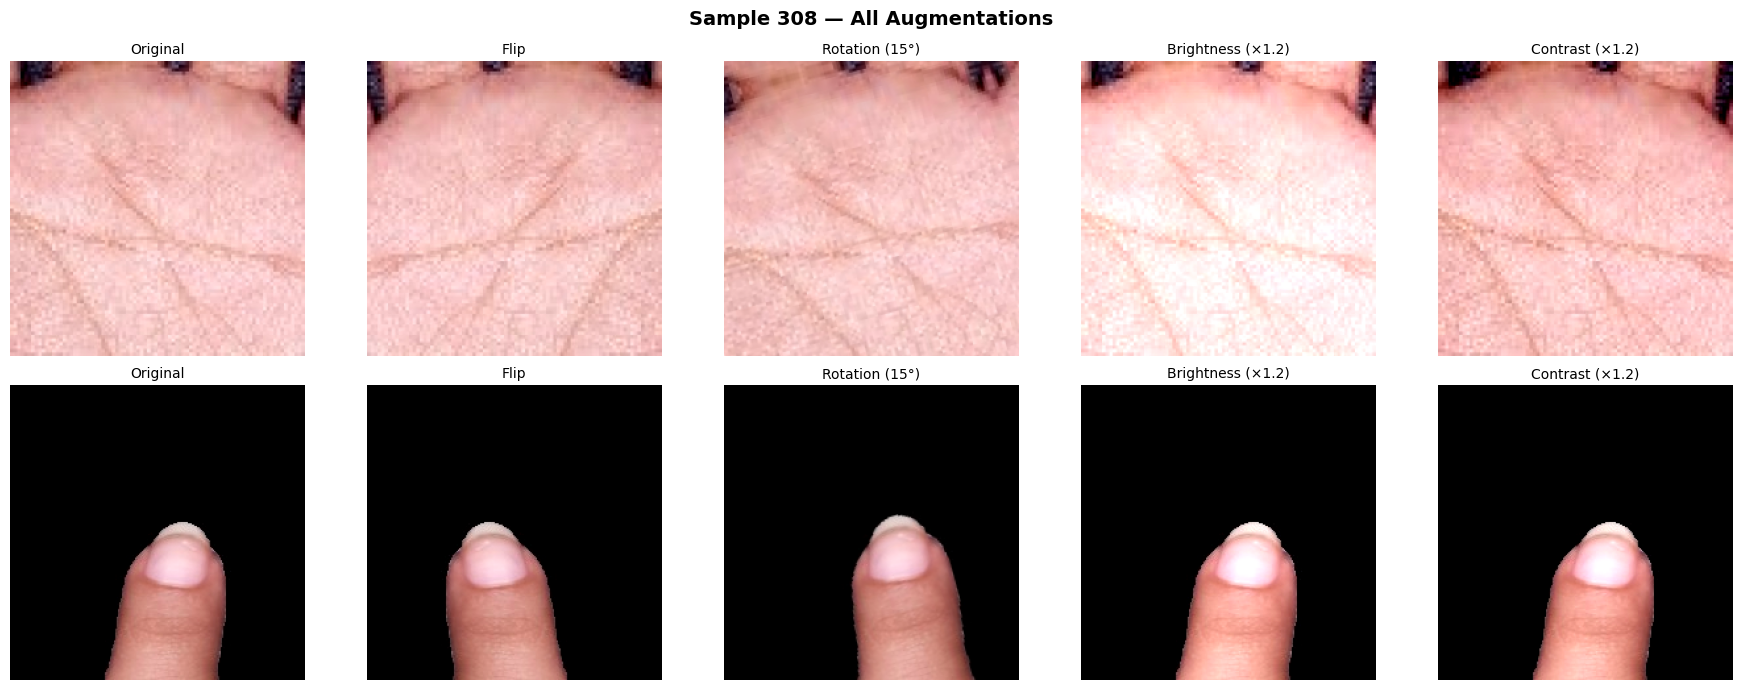

In [13]:
def visualise_one_sample(X_palm, X_nail, idx=None):
    if idx is None:
        idx = np.random.randint(0, len(X_palm))
    
    img_palm = (X_palm[idx] * 255).astype(np.uint8)
    img_nail = (X_nail[idx] * 255).astype(np.uint8)
    
    titles = ['Original', 'Flip', 'Rotation (15°)', 'Brightness (×1.2)', 'Contrast (×1.2)']
    
    palm_imgs = [img_palm] + [(a * 255).astype(np.uint8) for a in augment_image (X_palm[idx])]
    nail_imgs = [img_nail] + [(a * 255).astype(np.uint8) for a in augment_image (X_nail[idx])]
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(f'Sample {idx} — All Augmentations', fontsize=14, fontweight='bold')
    
    for col in range(5):
        axes[0, col].imshow(palm_imgs[col])
        axes[0, col].set_title(titles[col], fontsize=10)
        axes[0, col].axis('off')
        
        axes[1, col].imshow(nail_imgs[col])
        axes[1, col].set_title(titles[col], fontsize=10)
        axes[1, col].axis('off')
    
    axes[0, 0].set_ylabel('Palm', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Nail', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

visualise_one_sample(X_palm_train, X_nail_train)

# Models - Experimentation

In [14]:
import importlib
import Backbones, Attention, Build

importlib.reload(Backbones)
importlib.reload(Attention)
importlib.reload(Build)

from Build import build_models

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=10,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        patience=5,
        mode="max",
        factor=0.5,
        min_lr=1e-6
    )
]

In [30]:
def evaluate_model(name, model, history):

    val_scores  = model.evaluate([X_palm_val,  X_nail_val,  X_meta_val],  y_label_val,  verbose=0)
    test_scores = model.evaluate([X_palm_test, X_nail_test, X_meta_test], y_label_test, verbose=0)

    print(f"{name}")
    print(f"{'Metric':<20} {'Validation':>12} {'Test':>10}")
    print(f"{'AUC':<20} {val_scores[2]:>12.4f} {test_scores[2]:>10.4f}")
    print(f"{'Loss':<20} {val_scores[0]:>12.4f} {test_scores[0]:>10.4f}")

    # Youden's Threshold
    y_pred_prob = model.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()
    
    fpr, tpr, thresholds = roc_curve(y_label_test, y_pred_prob)
    youden_index          = tpr - fpr                          
    best_threshold        = thresholds[np.argmax(youden_index)]
    
    print(f"\n  Best Threshold (Youden): {best_threshold:.4f}")

    y_pred = (y_pred_prob > best_threshold).astype(int)

    #  Classification Report 
    print(f"\n Classification Report:")
    print(classification_report(y_label_test, y_pred,
                                target_names=["Non-Anemic", "Anemic"]))


    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(name, fontsize=14, fontweight="bold")

    # Plot 1 - AUC curve
    axes[0].plot(history.history["val_auc"],  label="val_auc")
    axes[0].plot(history.history["auc"],      label="train_auc")
    axes[0].set_title("AUC Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("AUC")
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2 - Loss curve
    axes[1].plot(history.history["val_loss"], label="val_loss")
    axes[1].plot(history.history["loss"],     label="train_loss")
    axes[1].set_title("Loss Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    # Plot 3 - Confusion matrix
    cm = confusion_matrix(y_label_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
                xticklabels=["Non-Anemic", "Anemic"],
                yticklabels=["Non-Anemic", "Anemic"])
    axes[2].set_title(f"Confusion Matrix\n(threshold={best_threshold:.2f})")
    axes[2].set_ylabel("Actual")
    axes[2].set_xlabel("Predicted")

    plt.tight_layout()
    plt.show()

## CNN_1

In [25]:
model_1 = build_models(backbone="cnn1",mode="classification")

In [26]:
model_1.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_1 = model_1.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 316s 4s/step - accuracy: 0.5647 - auc: 0.5886 - loss: 0.7604 - val_accuracy: 0.5823 - val_auc: 0.6173 - val_loss: 0.7452 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.6446 - auc: 0.6992 - loss: 0.6881 - val_accuracy: 0.6203 - val_auc: 0.5699 - val_loss: 0.7301 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.6745 - auc: 0.7284 - loss: 0.6653 - val_accuracy: 0.6203 - val_auc: 0.5804 - val_loss: 0.7200 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.6880 - auc: 0.7347 - loss: 0.6571 - val_accuracy: 0.4937 - val_auc: 0.6888 - val_loss: 0.7785 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.7136 - auc: 0.7750 - loss: 0.6204 - val_accuracy: 0.4937 - val_auc: 0.6253 - val_loss: 0.7796 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accura

CNN
Metric                 Validation       Test
AUC                        0.6888     0.6347
Loss                       0.7785     0.8060

  Best Threshold (Youden): 0.1509

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.76      0.40      0.52        40
      Anemic       0.59      0.88      0.71        40

    accuracy                           0.64        80
   macro avg       0.68      0.64      0.62        80
weighted avg       0.68      0.64      0.62        80



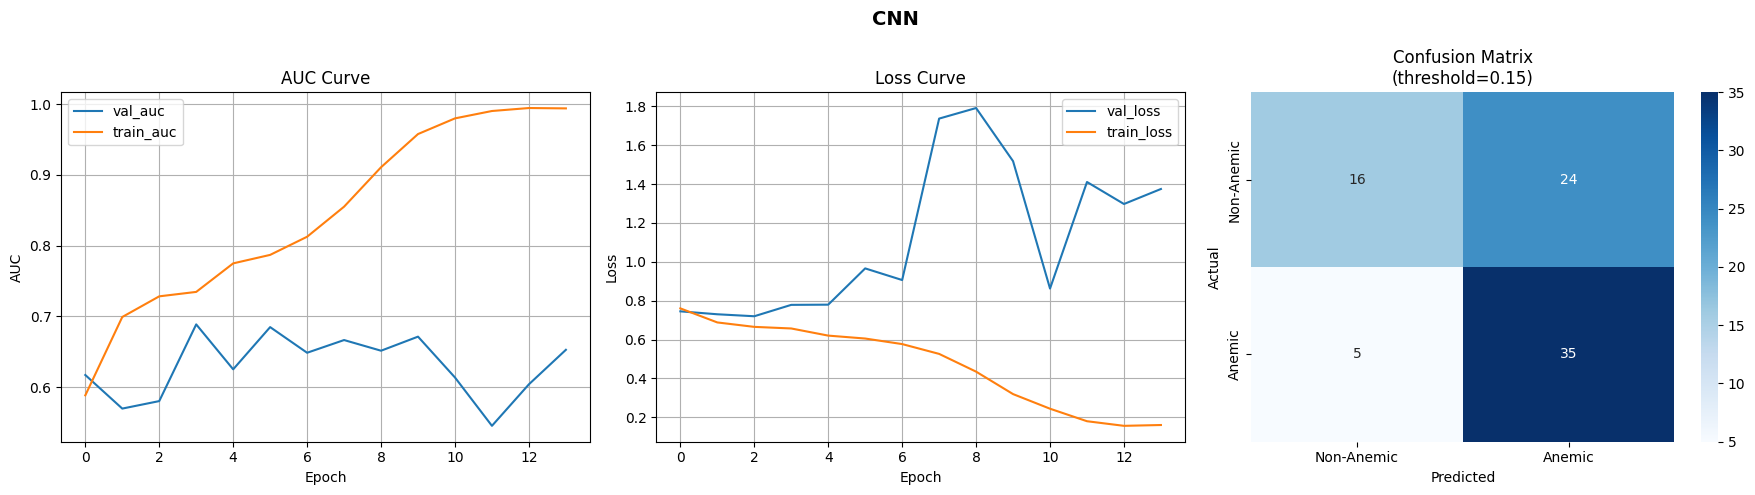

In [28]:
evaluate_model("CNN", model_1, history_1)

## CNN_2

In [34]:
model_2 = build_models(backbone="cnn2",mode="classification")

In [36]:
model_2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_2 = model_2.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.5826 - auc: 0.6245 - loss: 0.7261 - val_accuracy: 0.4937 - val_auc: 0.4660 - val_loss: 0.7672 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 231s 4s/step - accuracy: 0.6467 - auc: 0.6848 - loss: 0.6899 - val_accuracy: 0.5190 - val_auc: 0.5827 - val_loss: 0.7394 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.6750 - auc: 0.7130 - loss: 0.6662 - val_accuracy: 0.5063 - val_auc: 0.5769 - val_loss: 0.7352 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.6810 - auc: 0.7334 - loss: 0.6489 - val_accuracy: 0.4937 - val_auc: 0.5859 - val_loss: 0.8233 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.6799 - auc: 0.7182 - loss: 0.6570 - val_accuracy: 0.4937 - val_auc: 0.6526 - val_loss: 0.8565 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accura

CNN: Version 2
Metric                 Validation       Test
AUC                        0.6526     0.6781
Loss                       0.8565     0.8625

  Best Threshold (Youden): 0.2374

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.70      0.53      0.60        40
      Anemic       0.62      0.78      0.69        40

    accuracy                           0.65        80
   macro avg       0.66      0.65      0.64        80
weighted avg       0.66      0.65      0.64        80



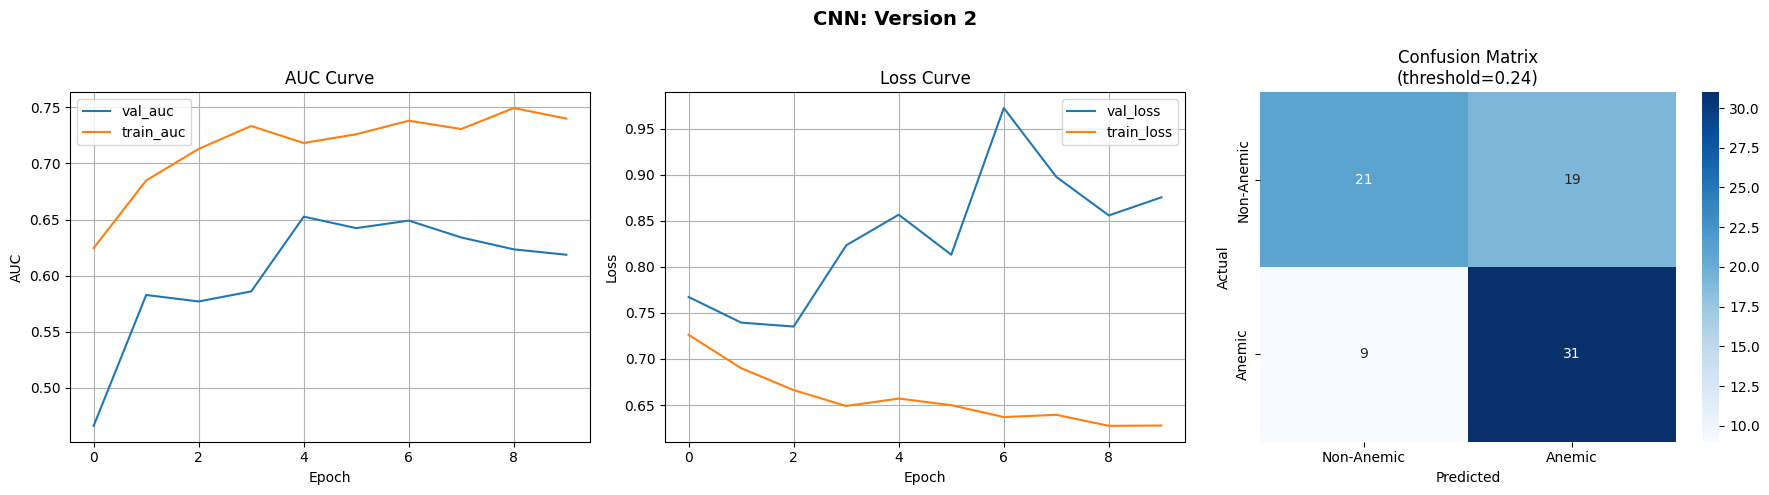

In [39]:
evaluate_model("CNN: Version 2", model_2, history_2)

## CNN_3

In [16]:
model_3 = build_models(backbone="cnn3",mode="classification")

In [19]:
model_3.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_3 = model_3.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.6413 - auc: 0.6927 - loss: 0.6975 - val_accuracy: 0.4937 - val_auc: 0.5622 - val_loss: 1.0044 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.6658 - auc: 0.7194 - loss: 0.6682 - val_accuracy: 0.4937 - val_auc: 0.6189 - val_loss: 1.3782 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.6875 - auc: 0.7407 - loss: 0.6518 - val_accuracy: 0.4937 - val_auc: 0.6029 - val_loss: 1.9066 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.6880 - auc: 0.7418 - loss: 0.6414 - val_accuracy: 0.4937 - val_auc: 0.5423 - val_loss: 1.9895 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 208s 4s/step - accuracy: 0.7065 - auc: 0.7557 - loss: 0.6234 - val_accuracy: 0.4937 - val_auc: 0.6029 - val_loss: 1.8033 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accura

CNN: Version 3
Metric                 Validation       Test
AUC                        0.6388     0.6687
Loss                       1.3414     1.3940

  Best Threshold (Youden): 0.0920

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.64      0.70      0.67        40
      Anemic       0.67      0.60      0.63        40

    accuracy                           0.65        80
   macro avg       0.65      0.65      0.65        80
weighted avg       0.65      0.65      0.65        80



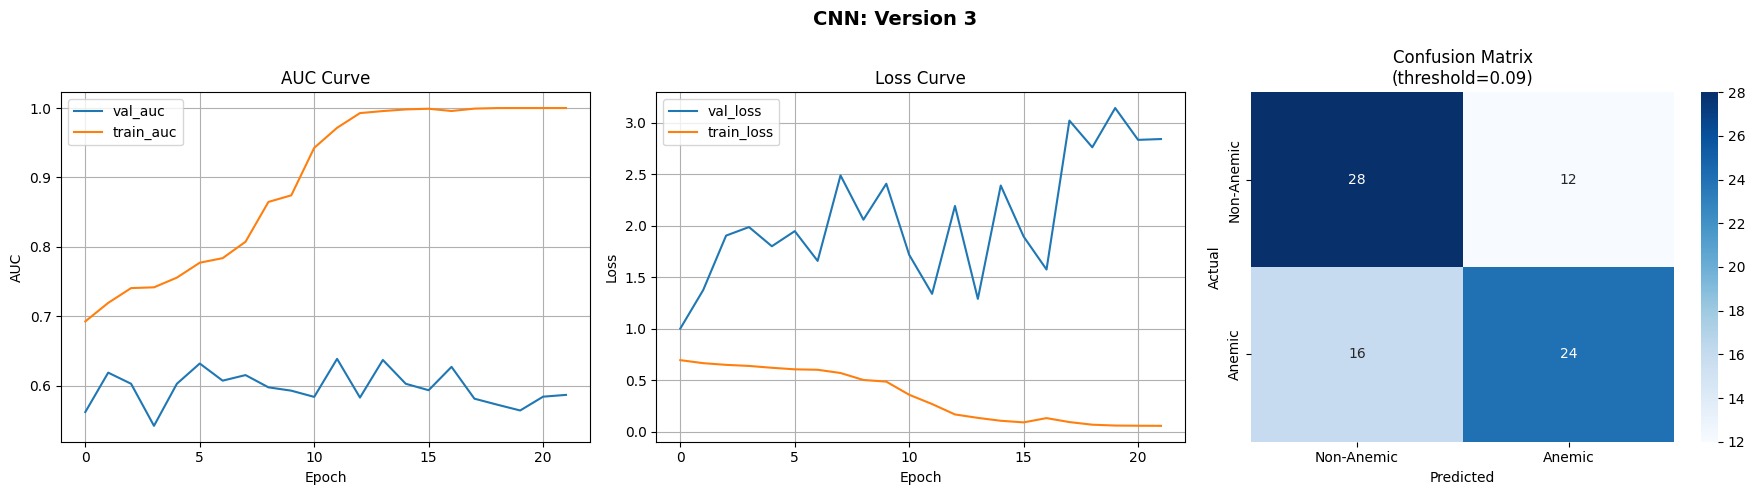

In [22]:
evaluate_model("CNN: Version 3", model_3, history_3)

## CNN_4

In [29]:
model_4 = build_models(backbone="cnn4",mode="classification")

In [30]:
model_4.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_4 = model_4.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 69s 931ms/step - accuracy: 0.5668 - auc: 0.5828 - loss: 0.7654 - val_accuracy: 0.6203 - val_auc: 0.6109 - val_loss: 0.7170 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 49s 835ms/step - accuracy: 0.6217 - auc: 0.6754 - loss: 0.7064 - val_accuracy: 0.6203 - val_auc: 0.5782 - val_loss: 0.7252 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 51s 886ms/step - accuracy: 0.6658 - auc: 0.6992 - loss: 0.6845 - val_accuracy: 0.6203 - val_auc: 0.5500 - val_loss: 0.7299 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 49s 838ms/step - accuracy: 0.6859 - auc: 0.7086 - loss: 0.6710 - val_accuracy: 0.6203 - val_auc: 0.5535 - val_loss: 0.7258 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 52s 892ms/step - accuracy: 0.6750 - auc: 0.7093 - loss: 0.6700 - val_accuracy: 0.6203 - val_auc: 0.6064 - val_loss: 0.7173 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 49s 839ms/s

CNN: Version 4
Metric                 Validation       Test
AUC                        0.7103     0.5975
Loss                       0.7062     0.7053

  Best Threshold (Youden): 0.6114

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.68      0.47      0.56        40
      Anemic       0.60      0.78      0.67        40

    accuracy                           0.62        80
   macro avg       0.64      0.62      0.62        80
weighted avg       0.64      0.62      0.62        80



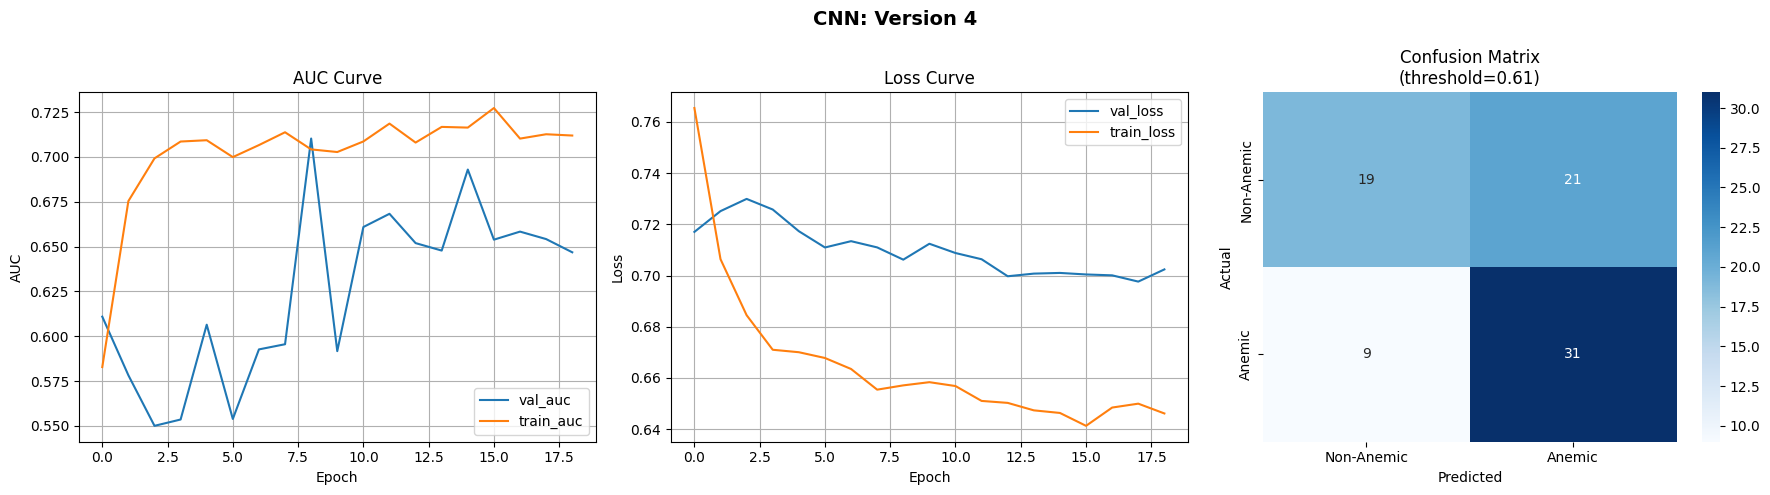

In [31]:
evaluate_model("CNN: Version 4", model_4, history_4)

## CNN_5

In [32]:
model_5 = build_models(backbone="cnn5",mode="classification")

In [33]:
model_5.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_5 = model_5.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 817s 13s/step - accuracy: 0.5875 - auc: 0.6186 - loss: 0.7378 - val_accuracy: 0.6203 - val_auc: 0.5413 - val_loss: 0.7293 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 424s 7s/step - accuracy: 0.6527 - auc: 0.6913 - loss: 0.6920 - val_accuracy: 0.6203 - val_auc: 0.5747 - val_loss: 0.7353 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 288s 5s/step - accuracy: 0.6859 - auc: 0.7057 - loss: 0.6740 - val_accuracy: 0.6203 - val_auc: 0.6349 - val_loss: 0.7324 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 370s 6s/step - accuracy: 0.6859 - auc: 0.7148 - loss: 0.6644 - val_accuracy: 0.6203 - val_auc: 0.6462 - val_loss: 0.7465 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 341s 6s/step - accuracy: 0.6967 - auc: 0.7060 - loss: 0.6625 - val_accuracy: 0.6203 - val_auc: 0.5449 - val_loss: 0.7204 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 296s 5s/step - accur

CNN: Version 5
Metric                 Validation       Test
AUC                        0.5413     0.6456
Loss                       0.7293     0.7171

  Best Threshold (Youden): 0.5295

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.68      0.47      0.56        40
      Anemic       0.60      0.78      0.67        40

    accuracy                           0.62        80
   macro avg       0.64      0.62      0.62        80
weighted avg       0.64      0.62      0.62        80



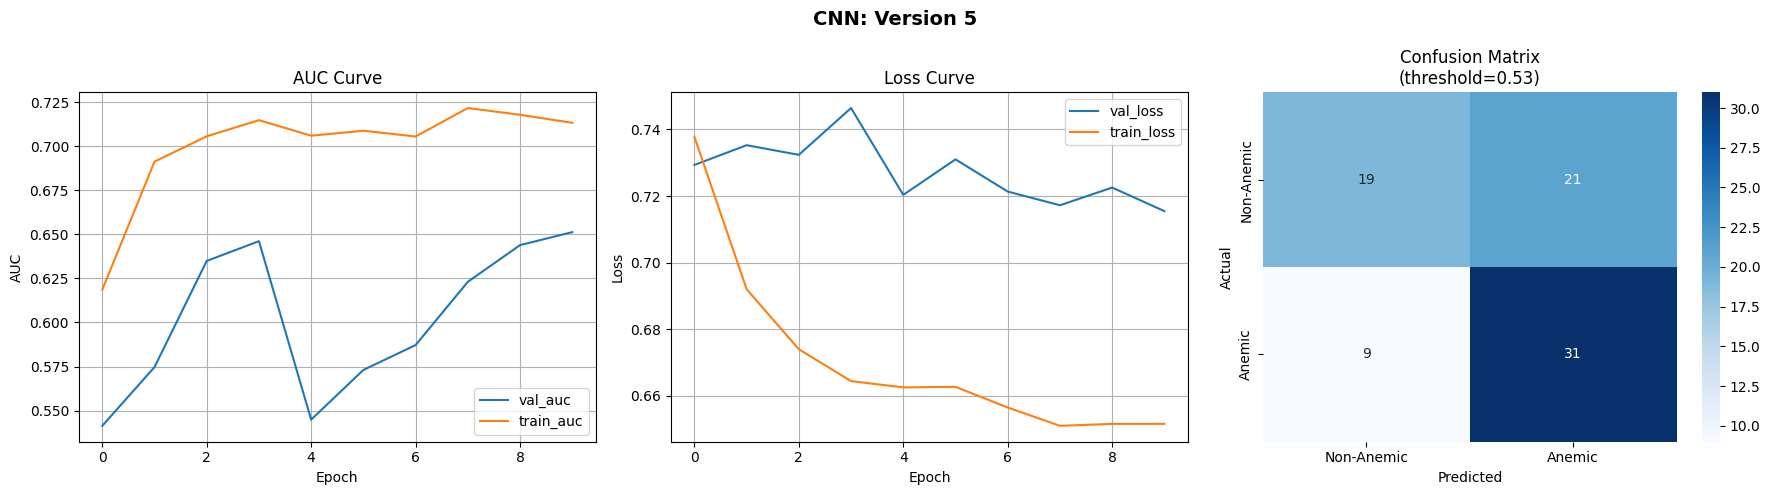

In [34]:
evaluate_model("CNN: Version 5", model_5, history_5)

## MobileNetV2

In [ ]:
model_6 = build_models(backbone="mobilenetv2",mode="classification")

In [ ]:
model_6.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_6 = model_6.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 77s 824ms/step - accuracy: 0.6223 - auc: 0.6662 - loss: 0.7093 - val_accuracy: 0.5443 - val_auc: 0.6391 - val_loss: 0.7379 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 49s 839ms/step - accuracy: 0.7380 - auc: 0.8180 - loss: 0.5808 - val_accuracy: 0.6076 - val_auc: 0.6109 - val_loss: 0.7206 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 50s 866ms/step - accuracy: 0.8261 - auc: 0.9091 - loss: 0.4483 - val_accuracy: 0.5190 - val_auc: 0.6478 - val_loss: 0.7535 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 818ms/step - accuracy: 0.9005 - auc: 0.9641 - loss: 0.3156 - val_accuracy: 0.5696 - val_auc: 0.6285 - val_loss: 0.8009 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 789ms/step - accuracy: 0.9495 - auc: 0.9888 - loss: 0.2116 - val_accuracy: 0.4937 - val_auc: 0.6385 - val_loss: 1.1356 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 791ms/s

MobileNet
Metric                 Validation       Test
AUC                        0.6776     0.5991
Loss                       1.5692     1.6892

  Best Threshold (Youden): 0.9156

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.69      0.45      0.55        40
      Anemic       0.59      0.80      0.68        40

    accuracy                           0.62        80
   macro avg       0.64      0.62      0.61        80
weighted avg       0.64      0.62      0.61        80



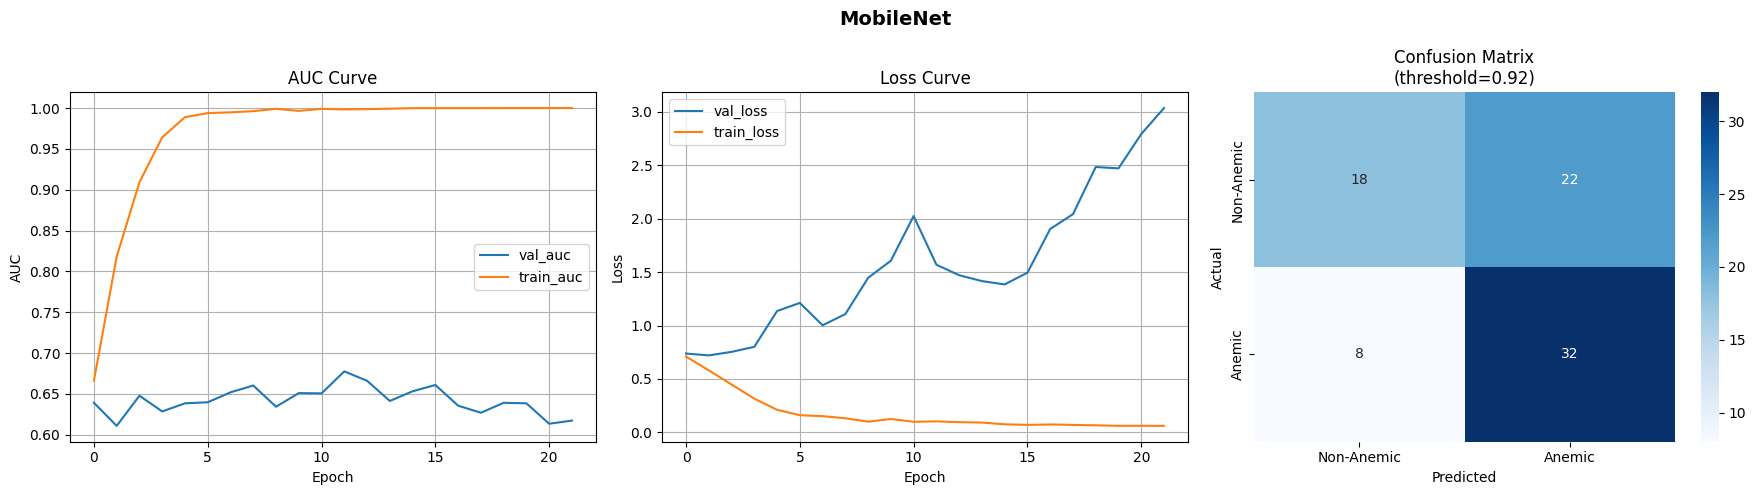

In [ ]:
evaluate_model("MobileNet", model_6, history_6)

## EfficientNetB0

In [ ]:
model_7 = build_models(backbone="efficientnetb0",mode="classification")

In [ ]:
model_7.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_7 = model_7.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.6967 - auc: 0.7013 - loss: 0.6596 - val_accuracy: 0.6203 - val_auc: 0.6183 - val_loss: 0.7100 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7011 - auc: 0.7106 - loss: 0.6540 - val_accuracy: 0.6203 - val_auc: 0.5712 - val_loss: 0.7090 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6940 - auc: 0.7163 - loss: 0.6508 - val_accuracy: 0.6203 - val_auc: 0.6304 - val_loss: 0.7074 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7033 - auc: 0.7162 - loss: 0.6455 - val_accuracy: 0.6203 - val_auc: 0.6317 - val_loss: 0.7070 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7027 - auc: 0.7115 - loss: 0.6494 - val_accuracy: 0.6203 - val_auc: 0.6442 - val_loss: 0.7046 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0

EfficientNetB0
Metric                 Validation       Test
AUC                        0.6183     0.6328
Loss                       0.7100     0.7134

  Best Threshold (Youden): 0.5384

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.68      0.47      0.56        40
      Anemic       0.60      0.78      0.67        40

    accuracy                           0.62        80
   macro avg       0.64      0.62      0.62        80
weighted avg       0.64      0.62      0.62        80



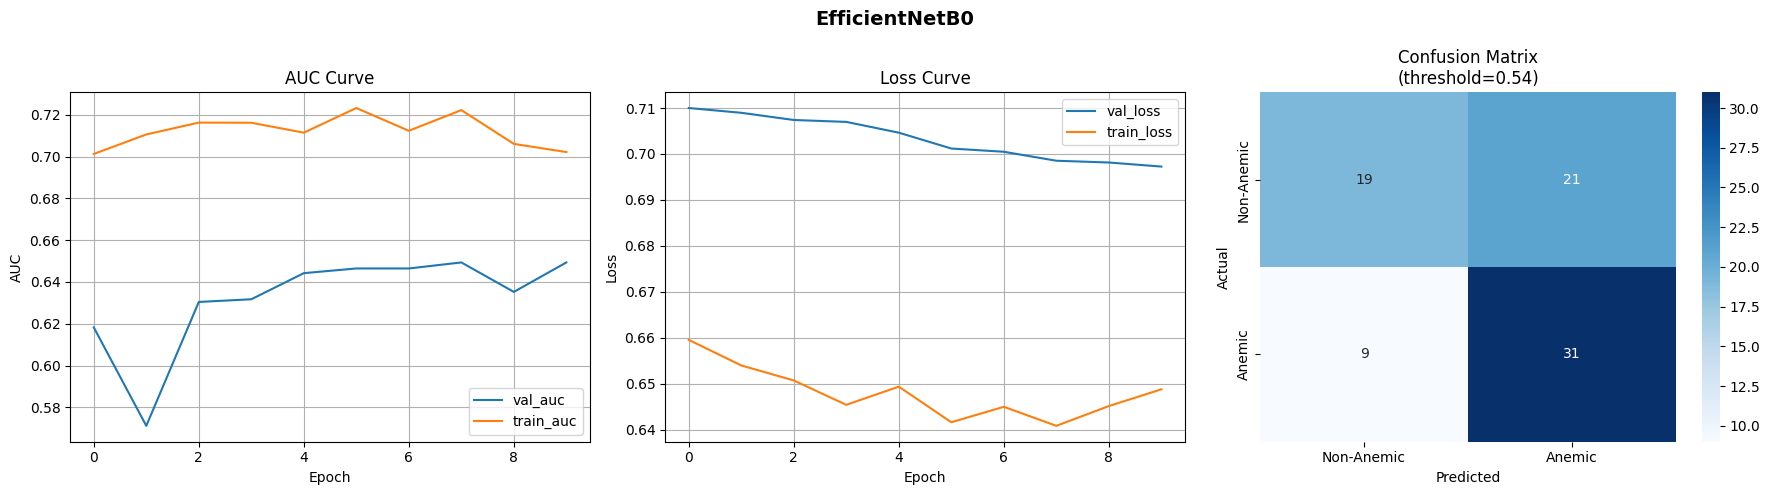

In [ ]:
evaluate_model("EfficientNetB0", model_7, history_7)

## DenseNet121

In [ ]:
model_8 = build_models(backbone="densenet121",mode="classification")

In [ ]:
model_8.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_8 = model_8.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.5989 - auc: 0.6316 - loss: 0.7515 - val_accuracy: 0.5443 - val_auc: 0.5311 - val_loss: 0.7788 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.7250 - auc: 0.7935 - loss: 0.6139 - val_accuracy: 0.5190 - val_auc: 0.5705 - val_loss: 0.8177 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.7837 - auc: 0.8720 - loss: 0.5080 - val_accuracy: 0.5696 - val_auc: 0.5862 - val_loss: 0.9016 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9011 - auc: 0.9651 - loss: 0.3172 - val_accuracy: 0.5696 - val_auc: 0.5779 - val_loss: 1.3806 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.9500 - auc: 0.9852 - loss: 0.2102 - val_accuracy: 0.5570 - val_auc: 0.5997 - val_loss: 1.5716 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accura

Densenet121
Metric                 Validation       Test
AUC                        0.5311     0.6644
Loss                       0.7788     0.7208

  Best Threshold (Youden): 0.4128

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.71      0.55      0.62        40
      Anemic       0.63      0.78      0.70        40

    accuracy                           0.66        80
   macro avg       0.67      0.66      0.66        80
weighted avg       0.67      0.66      0.66        80



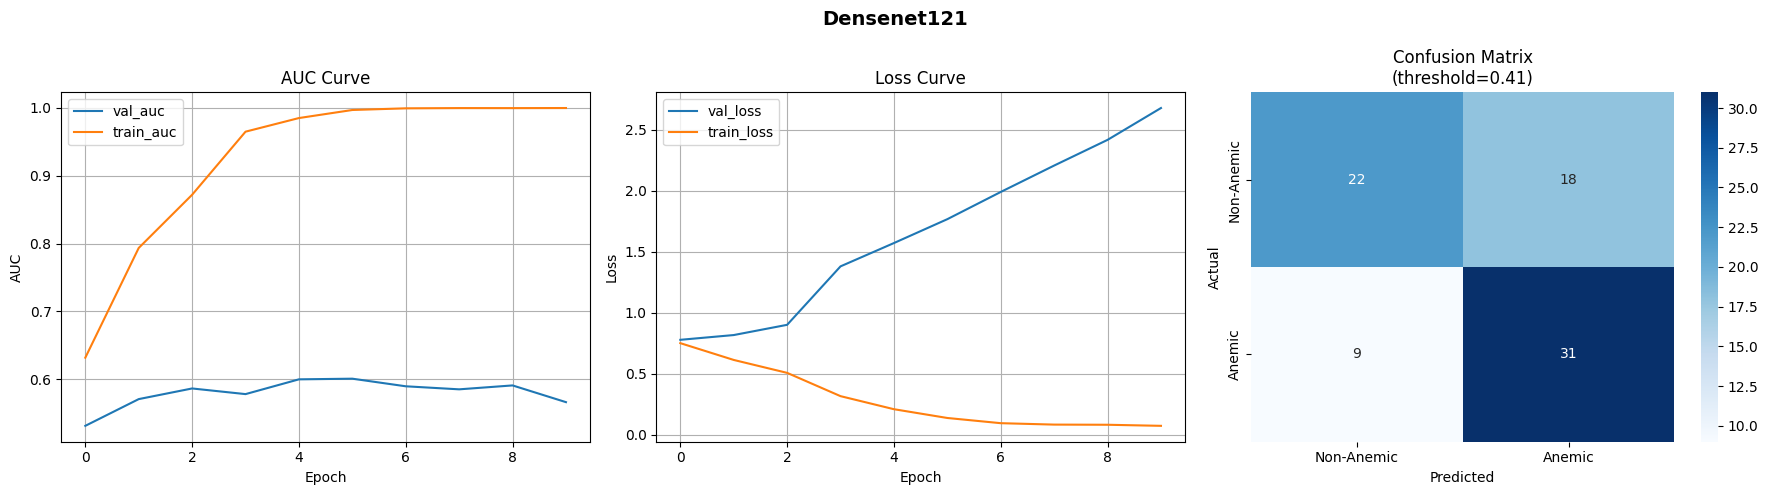

In [ ]:
evaluate_model("Densenet121", model_8, history_8)

## DenseNet121 _ Version 2
Tuned attention head to 4

In [ ]:
model_9 = build_models(backbone="densenet121",mode="classification")

In [ ]:
model_9.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_9 = model_9.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 754s 8s/step - accuracy: 0.5967 - auc: 0.6365 - loss: 0.7301 - val_accuracy: 0.6076 - val_auc: 0.5907 - val_loss: 0.7510 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 353s 6s/step - accuracy: 0.7234 - auc: 0.7976 - loss: 0.6097 - val_accuracy: 0.5949 - val_auc: 0.6234 - val_loss: 0.7865 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 345s 6s/step - accuracy: 0.8016 - auc: 0.8762 - loss: 0.5045 - val_accuracy: 0.5949 - val_auc: 0.6135 - val_loss: 0.9507 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 276s 5s/step - accuracy: 0.9065 - auc: 0.9634 - loss: 0.3128 - val_accuracy: 0.6076 - val_auc: 0.6301 - val_loss: 1.1926 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.9538 - auc: 0.9917 - loss: 0.1861 - val_accuracy: 0.5823 - val_auc: 0.6151 - val_loss: 1.7429 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accura

Densenet121 _Version 02
Metric                 Validation       Test
AUC                        0.6606     0.6531
Loss                       2.2050     2.1437

  Best Threshold (Youden): 0.0132

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.66      0.57      0.61        40
      Anemic       0.62      0.70      0.66        40

    accuracy                           0.64        80
   macro avg       0.64      0.64      0.64        80
weighted avg       0.64      0.64      0.64        80



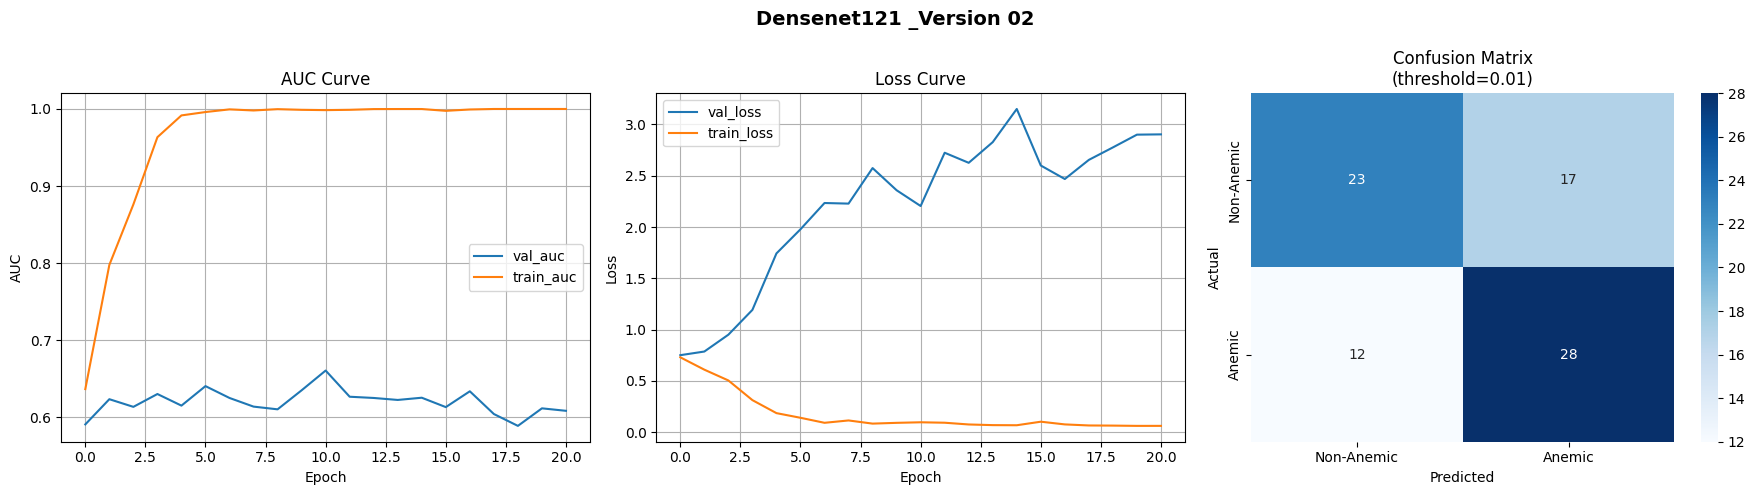

In [ ]:
evaluate_model("Densenet121 _Version 02", model_9, history_9)

## DenseNet169

In [ ]:
model_10 =build_models(backbone="densenet169", mode="classification")

In [ ]:
model_10.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", 
             tf.keras.metrics.AUC(name="AUC"),
             tf.keras.metrics.Precision(name="Precision"),
             tf.keras.metrics.Recall(name="Recall")]
)


history_10 = model_10.fit(
    x=[X_palm_train, X_nail_train, X_meta_train],
    y=y_label_train,
    validation_data=([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - AUC: 0.6647 - Precision: 0.6292 - Recall: 0.6380 - accuracy: 0.6310 - loss: 0.7232 - val_AUC: 0.5833 - val_Precision: 0.5763 - val_Recall: 0.8500 - val_accuracy: 0.6076 - val_loss: 0.7521 - learning_rate: 1.0000e-04
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - AUC: 0.8095 - Precision: 0.7159 - Recall: 0.7804 - accuracy: 0.7353 - loss: 0.5857 - val_AUC: 0.6151 - val_Precision: 0.5645 - val_Recall: 0.8750 - val_accuracy: 0.5949 - val_loss: 0.8117 - learning_rate: 1.0000e-04
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - AUC: 0.9321 - Precision: 0.8471 - Recall: 0.8793 - accuracy: 0.8603 - loss: 0.4080 - val_AUC: 0.6147 - val_Precision: 0.5205 - val_Recall: 0.9500 - val_accuracy: 0.5316 - val_loss: 1.2520 - learning_rate: 1.0000e-04
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - AUC: 0.9884 - Precision: 0.9443 - Recall: 0.9576 - accuracy: 0.9505 - loss: 0.2104 - val_AUC: 0.6260 - val_Precision: 0.5439 - val_Recall: 0

densent
Metric                 Validation       Test
AUC                        0.6410     0.6575
Loss                       1.6586     1.5721

  Best Threshold (Youden): 0.6334

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.64      0.62      0.63        40
      Anemic       0.63      0.65      0.64        40

    accuracy                           0.64        80
   macro avg       0.64      0.64      0.64        80
weighted avg       0.64      0.64      0.64        80



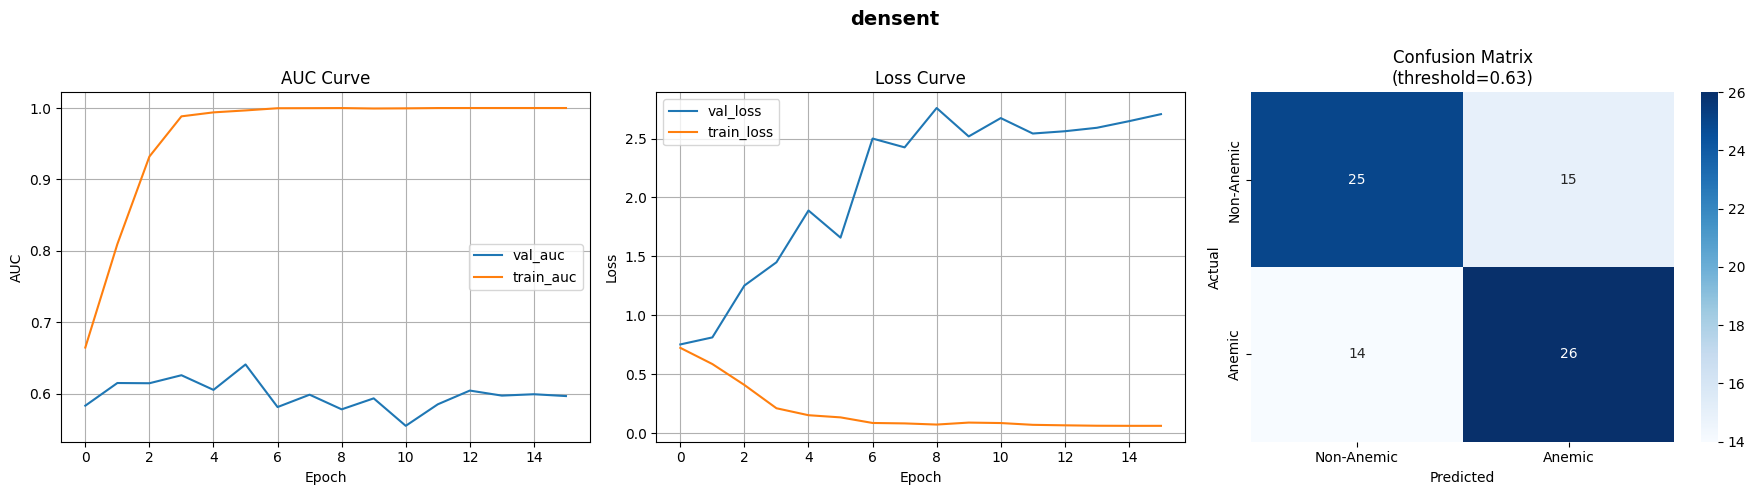

In [ ]:
evaluate_model("densent",model_10,history_10)

## ResNet50

In [35]:
model_11 = build_models(backbone="resnet50",mode="classification")

In [36]:
model_11.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_11 = model_11.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 348s 5s/step - accuracy: 0.6734 - auc: 0.7329 - loss: 0.6659 - val_accuracy: 0.5696 - val_auc: 0.5917 - val_loss: 0.7769 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.8701 - auc: 0.9449 - loss: 0.3753 - val_accuracy: 0.5443 - val_auc: 0.5747 - val_loss: 1.2791 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 303s 5s/step - accuracy: 0.9750 - auc: 0.9966 - loss: 0.1428 - val_accuracy: 0.5443 - val_auc: 0.5410 - val_loss: 2.1574 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 585s 10s/step - accuracy: 0.9750 - auc: 0.9966 - loss: 0.1297 - val_accuracy: 0.5696 - val_auc: 0.6237 - val_loss: 2.0565 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 359s 6s/step - accuracy: 0.9788 - auc: 0.9974 - loss: 0.1247 - val_accuracy: 0.5949 - val_auc: 0.6160 - val_loss: 2.0967 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 701s 12s/step - accu

ResNet50
Metric                 Validation       Test
AUC                        0.5917     0.6837
Loss                       0.7769     0.7069

  Best Threshold (Youden): 0.3857

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.71      0.55      0.62        40
      Anemic       0.63      0.78      0.70        40

    accuracy                           0.66        80
   macro avg       0.67      0.66      0.66        80
weighted avg       0.67      0.66      0.66        80



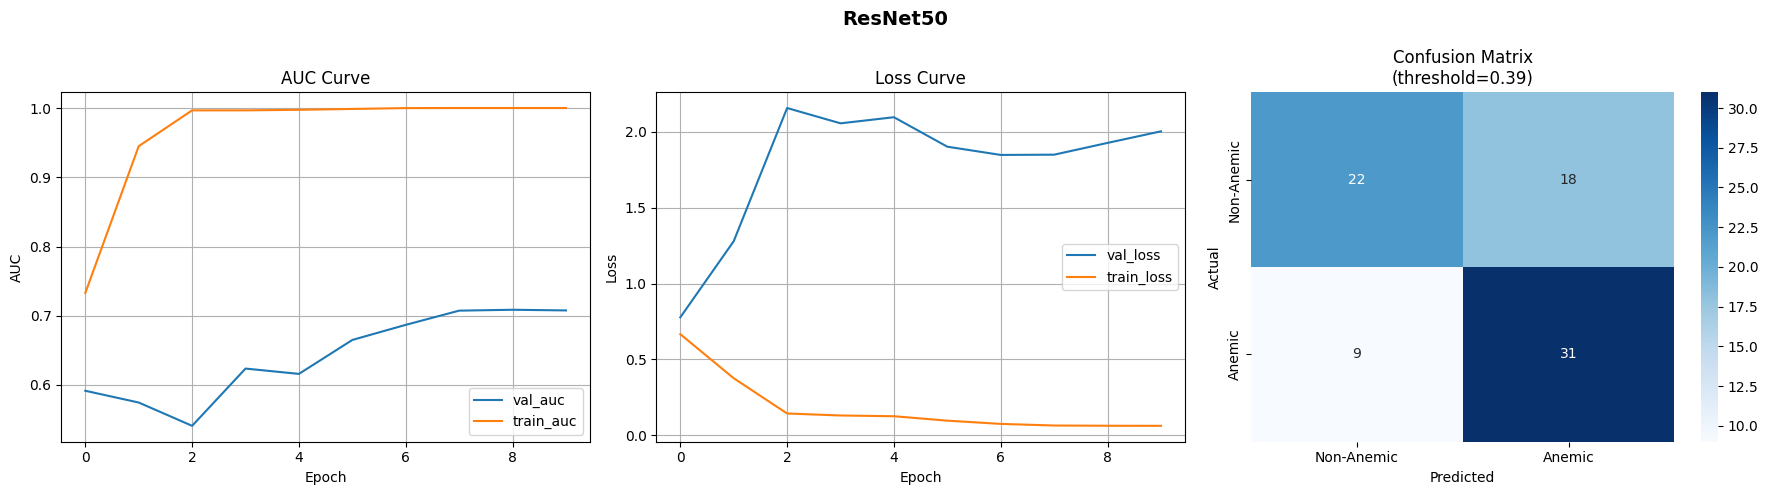

In [37]:
evaluate_model("ResNet50", model_11, history_11)

# Comparision Table

In [62]:
# ── Final Comparison Table ───────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

THRESHOLD = 0.5

all_models = [
    ("CNN1",           model_1),
    ("CNN2",           model_2),
    ("MobileNetV2",    model_3),
    ("EfficientNetB0", model_4),
    ("DenseNet121",    model_5),
]

results = []
for name, model in all_models:
    y_prob_val  = model.predict([X_palm_val,  X_nail_val,  X_meta_val],  verbose=0).flatten()
    y_prob = model.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).flatten()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    results.append({
        "Model"     : name,
        "Val AUC"   : round(roc_auc_score(y_label_val,  y_prob_val),  4),  # for backbone selection
        "Test AUC"  : round(roc_auc_score(y_label_test, y_prob), 4),
        "Accuracy"  : round(accuracy_score(y_label_test, y_pred), 4),
        "Precision" : round(precision_score(y_label_test, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_label_test, y_pred, zero_division=0), 4),
        "F1"        : round(f1_score(y_label_test, y_pred, zero_division=0), 4),
    })

df = pd.DataFrame(results).sort_values("Val AUC", ascending=False).reset_index(drop=True)
df.index += 1  # start ranking from 1

print(f"\n{'='*65}")
print(f"  FINAL MODEL COMPARISON — Threshold = {THRESHOLD}")
print(f"{'='*65}")
print(df.to_string())
print(f"\n✅ Best Backbone (by Val AUC): {df.iloc[0]['Model']} (Val AUC = {df.iloc[0]['Val AUC']}, Test AUC = {df.iloc[0]['Test AUC']})")


  FINAL MODEL COMPARISON — Threshold = 0.5
            Model  Val AUC  Test AUC  Accuracy  Precision  Recall      F1
1     MobileNetV2   0.6635    0.5969    0.5375     0.5224   0.875  0.6542
2            CNN2   0.6513    0.6800    0.5000     0.0000   0.000  0.0000
3  EfficientNetB0   0.6135    0.6344    0.6250     0.5926   0.800  0.6809
4            CNN1   0.5795    0.6206    0.5875     0.6000   0.525  0.5600
5     DenseNet121   0.5308    0.6638    0.6375     0.6571   0.575  0.6133

✅ Best Backbone (by Val AUC): MobileNetV2 (Val AUC = 0.6635, Test AUC = 0.5969)
